In [3]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# 1. Define Image Transformations (Standard for Medical Images)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Path for Kaggle Dataset (Update based on the dataset structure)
# The dataset has 'train', 'test', and 'valid' folders
base_path = '/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data'
test_dir = os.path.join(base_path, 'test')

# Load dataset using ImageFolder
test_dataset = ImageFolder(test_dir, transform=transform)
class_names = test_dataset.classes

print(f"Classes identified: {class_names}")
print(f"Total test images: {len(test_dataset)}")

Classes identified: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Total test images: 315


In [4]:
# 1. Load Pre-trained DenseNet121 Model
print("Initializing DenseNet121 for Medical Imaging...")
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# 2. Modify Classifier for 4 classes (Adeno, Large cell, Squamous, Normal)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, len(class_names))

# 3. Set model to evaluation mode
model.eval()
print("Model loaded and output layer updated successfully.")

Initializing DenseNet121 for Medical Imaging...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 141MB/s] 


Model loaded and output layer updated successfully.


In [6]:
# Install Captum library
!pip install -q captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 66.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].


Captum viz failed, using basic Matplotlib: axis 2 is out of bounds for array of dimension 2


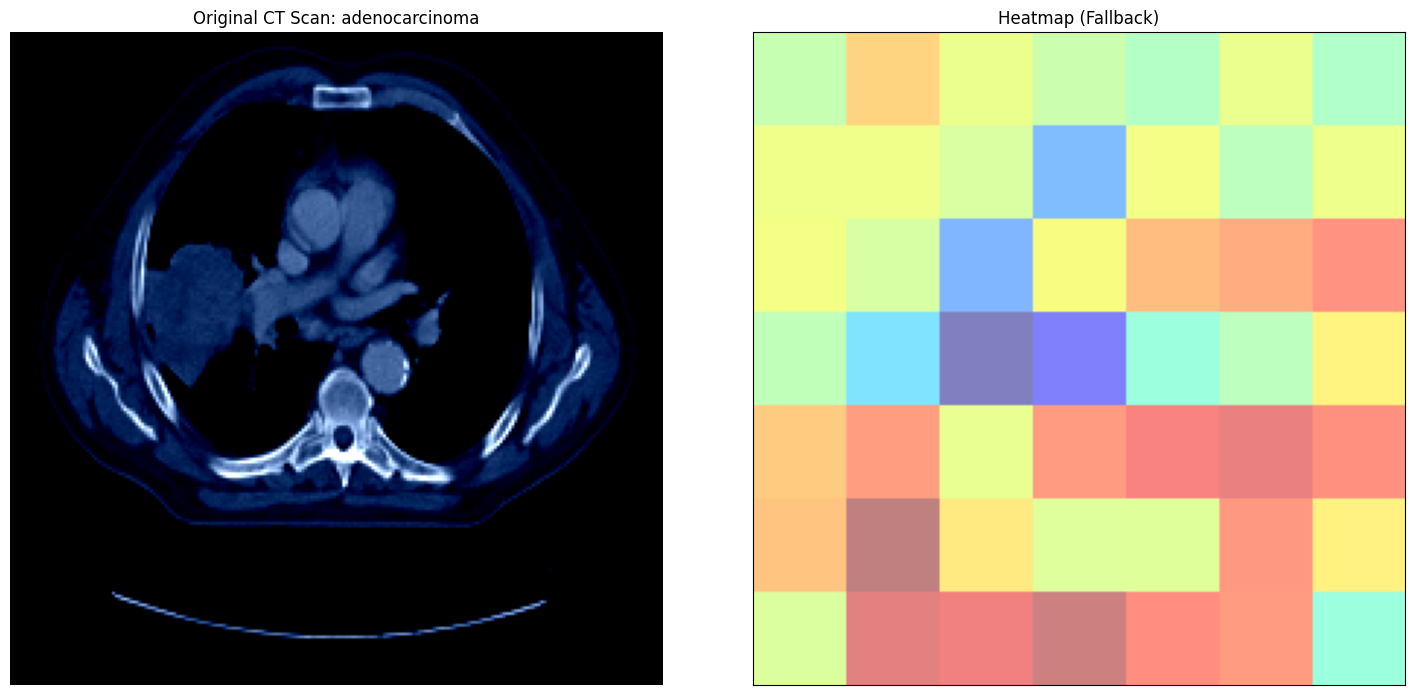

In [8]:
from captum.attr import LayerGradCam
from captum.attr import visualization as viz

# 1. Setup LayerGradCam on the last feature layer of DenseNet
lgc = LayerGradCam(model, model.features.norm5)

# 2. Select a sample image
idx = 20 
input_tensor, label = test_dataset[idx]
input_batch = input_tensor.unsqueeze(0)

# 3. Model Prediction
output = model(input_batch)
_, pred_label_idx = torch.max(output, 1)

# 4. Generate Heatmap Attribution
attributions = lgc.attribute(input_batch, target=pred_label_idx)
upsampled_attr = LayerGradCam.interpolate(attributions, (224, 224))

# --- FIXED TRANSPOSE LOGIC ---
# Get NumPy arrays
attr_np = upsampled_attr.squeeze().cpu().detach().numpy()
img_np = input_tensor.cpu().detach().numpy()

# Ensure the attributes and image are in (H, W, C) format for visualization
if len(attr_np.shape) == 3:
    vis_attr = np.transpose(attr_np, (1, 2, 0))
else:
    # If it's a 2D array, we just need to keep it as is
    vis_attr = attr_np

# Ensure image is (H, W, C)
if len(img_np.shape) == 3:
    vis_img = np.transpose(img_np, (1, 2, 0))
else:
    vis_img = img_np
# -----------------------------

# 5. Final Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Display original CT Scan
ax[0].imshow(vis_img)
ax[0].set_title(f"Original CT Scan: {class_names[label]}", fontsize=12)
ax[0].axis('off')

# Display Grad-CAM Analysis
try:
    _ = viz.visualize_image_attr(
        vis_attr, vis_img, method="heatmap", sign="all", 
        show_colorbar=True, title="XAI: Tumor Localization (Grad-CAM)", plt_fig_axis=(fig, ax[1])
    )
except Exception as e:
    print(f"Captum viz failed, using basic Matplotlib: {e}")
    ax[1].imshow(vis_attr, cmap='jet', alpha=0.5)
    ax[1].set_title("Heatmap (Fallback)")

plt.tight_layout()
plt.show()

# 6. Save result
fig.savefig('lung_cancer_gradcam_analysis.png', dpi=300)

In [9]:
fig.savefig('lung_cancer_xai_output.png', dpi=300)
print("Saved result as 'lung_cancer_xai_output.png'")

Saved result as 'lung_cancer_xai_output.png'
